# <center><strong>Smart Farming Data Analysis & Prediction</strong></center>
-------------------

#### **By Mohamed Jamyl**

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------------------------
# <center><strong>Overview</strong></center>
-------------------------------------------

The Smart Farming 2024 (SF24) dataset is a comprehensive collection of agricultural data gathered from various farms across California, designed to enhance crop health monitoring and environmental stress assessment. This dataset is particularly valuable for researchers and developers focused on predictive modeling, machine learning, and data-driven agriculture solutions.

Features:
The dataset contains 4800 records with 28 features (23 original features and 5 derived features), each representing critical environmental and soil parameters, along with specific crop-related metrics. These features include:

N (ppm): Nitrogen content in the soil.

P (ppm): Phosphorus content in the soil.

K (ppm): Potassium content in the soil.

Temperature (°C): Ambient temperature recorded at the farm.

Humidity (%): Relative humidity at the location.

pH: Soil pH level, indicating acidity or alkalinity.

Rainfall (mm): Amount of rainfall received.

Label: Type of crop associated with the recorded conditions (e.g., rice).

Soil Moisture (%): Percentage of water content in the soil.

Soil Type: Type of soil (1 = Sandy, 2 = Loamy, 3 = Clay).

Sunlight Exposure (hrs/day): Average daily sunlight exposure.

Wind Speed (km/h): Wind speed at the farm.

CO2 Concentration (ppm): Carbon dioxide concentration in the air.

Organic Matter (%): Percentage of organic material in the soil.

Irrigation Frequency (times/week): Frequency of irrigation.

Crop Density (plants/m²): Number of plants per square meter.

Pest Pressure (index): Level of pest infestation.

Fertilizer Usage (kg/hectare): Amount of fertilizer applied per hectare.

Growth Stage: Current growth stage of the crop (1 = Seedling, 2 = Vegetative, 3 = Flowering).

Urban Area Proximity (km): Distance to the nearest urban area.

Water Source Type: Type of water source used for irrigation (1 = River, 2 = Groundwater, 3 = Recycled).

Frost Risk (index): Risk of frost occurrence.

Water Usage Efficiency (L/kg): Efficiency of water usage per kilogram of crop yield.

Derived Features:

In addition to the original attributes, the dataset includes 5 derived features that provide deeper insights into the interactions between environmental conditions and crop performance:

Temperature-Humidity Index (THI): A composite measure that evaluates potential crop stress due to specific heat and moisture conditions.

Nutrient Balance Ratio (NBR): Reflects the balance between nitrogen, phosphorus, and potassium in the soil.

Water Availability Index (WAI): Combines soil moisture and rainfall to assess overall water availability for crops.

Photosynthesis Potential (PP): Estimates the potential for photosynthesis based on sunlight exposure, CO2 concentration, and temperature.

Soil Fertility Index (SFI): A composite metric that assesses soil fertility based on organic matter content and NPK levels.

--------------------------------
--------------------------------
## **Import Libraries**
--------------------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

------------------------------------------
## **Initial functions**
------------------------------------------

In [3]:
def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.xlabel(col)
    plt.show()

def boxplot(data, col):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(8, 4)
    sns.boxplot(data=data,x=col,orient="o",ax=axes)
    plt.show()

def boxplot2(data, x,y):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(10, 5)
    sns.boxplot(data=data,y=y,x=x,orient="v",ax=axes)
    plt.show()

def kde(data, col):
    plt.figure(figsize=(8,	4))
    sns.kdeplot(data=data, x=col, fill=True, color='violet', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.show()

def kdeSep(data,x,hue):
    plt.figure(figsize=(12,	5))
    sns.kdeplot(data=data, x=x, hue=hue, fill=True)
    plt.show()

def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.title(col)
    plt.show()

def group_distribution(data,col,target):

    groups = data[col].unique()
    
    plt.figure(figsize=(12, 6))
    
    for i, group in enumerate(groups):
        data_group = data[data[col] == group][target]
        
        plt.subplot(2, 2, i+1)
        sns.histplot(data_group, kde=True, color='green')
        plt.title(f'Distribution for {group}')
    
    plt.tight_layout()
    plt.show()

---------------------------------------
## **Data Exploring**
---------------------------------------

In [4]:
df = pd.read_csv('Crop_recommendation.csv')

In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.88,82.00,6.50,202.94,rice,29.45,2,...,3.12,4,11.74,57.61,188.19,1,2.72,3,95.65,1.19
1,85,58,41,21.77,80.32,7.04,226.66,rice,12.85,3,...,2.14,4,16.80,74.74,70.96,1,4.71,2,77.27,1.75
2,60,55,44,23.00,82.32,7.84,263.96,rice,29.36,2,...,1.47,1,12.65,1.03,191.98,1,30.43,2,18.19,3.04
3,74,35,40,26.49,80.16,6.98,242.86,rice,26.21,3,...,8.39,1,10.86,24.09,55.76,3,10.86,3,82.82,1.27
4,78,42,42,20.13,81.60,7.63,262.72,rice,28.24,2,...,5.20,3,13.85,38.81,185.26,2,47.19,3,25.47,2.58


In [6]:
df.shape

(2200, 23)

In [7]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed',
       'co2_concentration', 'organic_matter', 'irrigation_frequency',
       'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage',
       'urban_area_proximity', 'water_source_type', 'frost_risk',
       'water_usage_efficiency'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   N                       2200 non-null   int64  
 1   P                       2200 non-null   int64  
 2   K                       2200 non-null   int64  
 3   temperature             2200 non-null   float64
 4   humidity                2200 non-null   float64
 5   ph                      2200 non-null   float64
 6   rainfall                2200 non-null   float64
 7   label                   2200 non-null   object 
 8   soil_moisture           2200 non-null   float64
 9   soil_type               2200 non-null   int64  
 10  sunlight_exposure       2200 non-null   float64
 11  wind_speed              2200 non-null   float64
 12  co2_concentration       2200 non-null   float64
 13  organic_matter          2200 non-null   float64
 14  irrigation_frequency    2200 non-null   

In [9]:
df.isnull().sum()

N                         0
P                         0
K                         0
temperature               0
humidity                  0
ph                        0
rainfall                  0
label                     0
soil_moisture             0
soil_type                 0
sunlight_exposure         0
wind_speed                0
co2_concentration         0
organic_matter            0
irrigation_frequency      0
crop_density              0
pest_pressure             0
fertilizer_usage          0
growth_stage              0
urban_area_proximity      0
water_source_type         0
frost_risk                0
water_usage_efficiency    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,soil_type,sunlight_exposure,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,...,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616136,71.481877,6.469445,103.463691,20.151323,1.991364,8.570514,...,5.465505,3.515000,12.344923,49.850764,125.846505,1.999545,24.801009,2.003636,50.304605,2.990314
std,36.917334,32.985883,50.647931,5.063700,22.263811,0.773905,54.958311,5.793727,0.812263,1.999387,...,2.605342,1.697912,4.297616,28.886296,43.564622,0.818999,14.524006,0.812021,28.580385,1.139684
min,0.000000,5.000000,5.000000,8.830000,14.260000,3.500000,20.210000,10.020000,1.000000,5.000000,...,1.000000,1.000000,5.000000,0.040000,50.210000,1.000000,0.020000,1.000000,0.050000,1.000000
25%,21.000000,28.000000,20.000000,22.770000,60.262500,5.970000,64.552500,15.180000,1.000000,6.907500,...,3.200000,2.000000,8.587500,24.377500,88.032500,1.000000,12.210000,1.000000,26.107500,2.050000
50%,37.000000,51.000000,32.000000,25.600000,80.470000,6.425000,94.865000,20.090000,2.000000,8.610000,...,5.420000,4.000000,12.305000,49.985000,126.440000,2.000000,24.920000,2.000000,50.170000,2.970000
75%,84.250000,68.000000,49.000000,28.560000,89.950000,6.920000,124.270000,25.252500,3.000000,10.220000,...,7.690000,5.000000,15.972500,74.680000,163.852500,3.000000,37.320000,3.000000,75.262500,3.970000
max,140.000000,145.000000,205.000000,43.680000,99.980000,9.940000,298.560000,30.000000,3.000000,11.990000,...,10.000000,6.000000,19.990000,99.980000,199.980000,3.000000,49.990000,3.000000,99.960000,5.000000


In [12]:
df.select_dtypes(include='object').describe()

,label
count,2200
unique,22
top,rice
freq,100


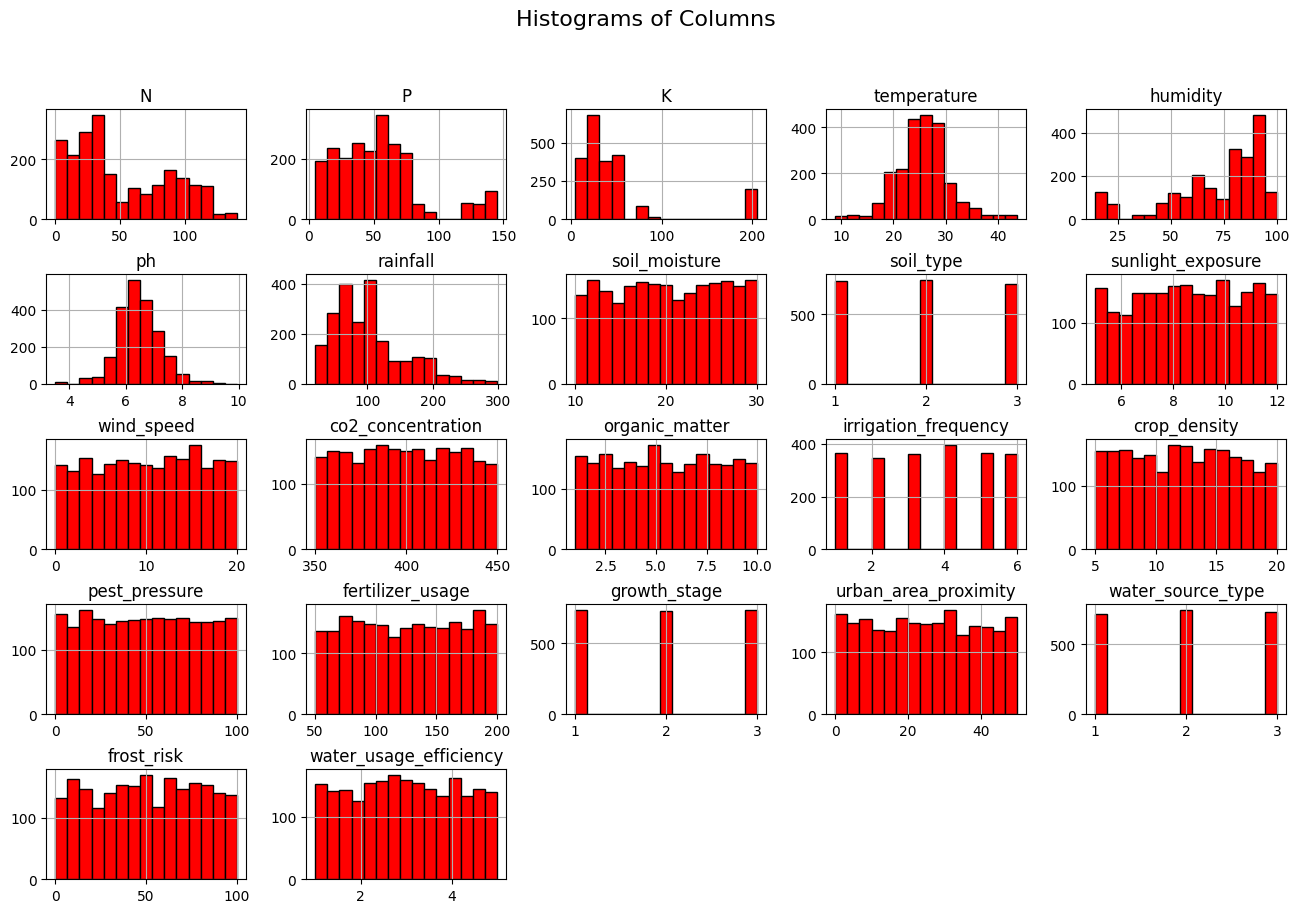

In [13]:
df.hist(bins=15, figsize=(16, 10), color='red', edgecolor='black')
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  
plt.show()

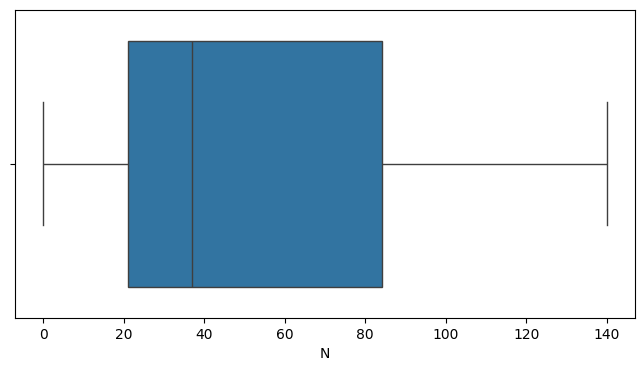

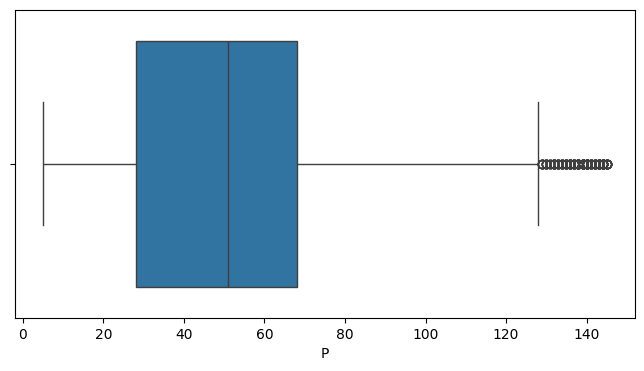

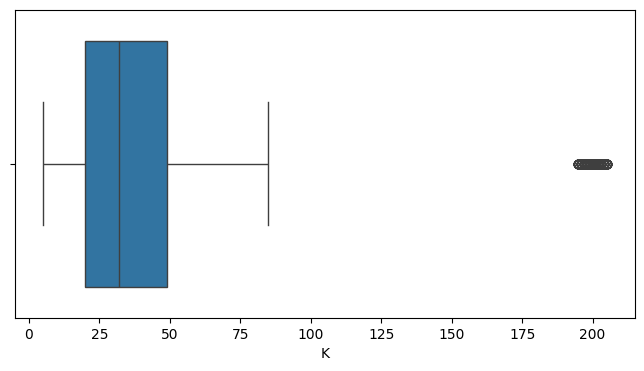

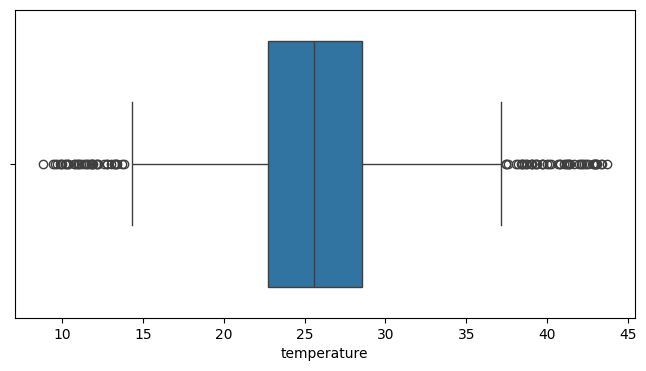

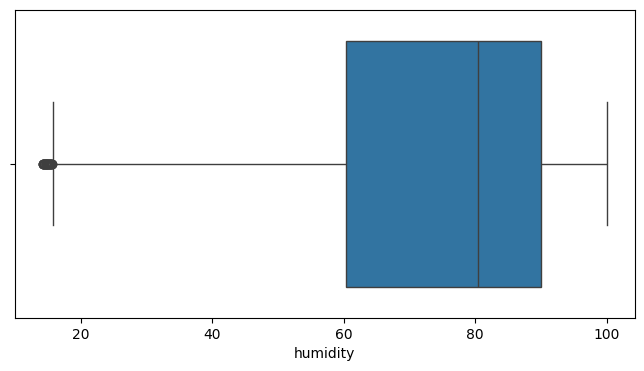

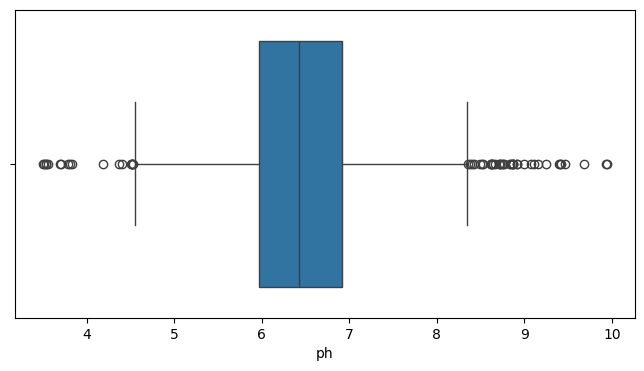

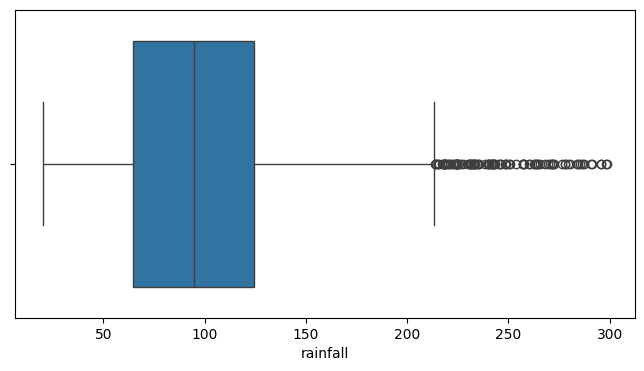

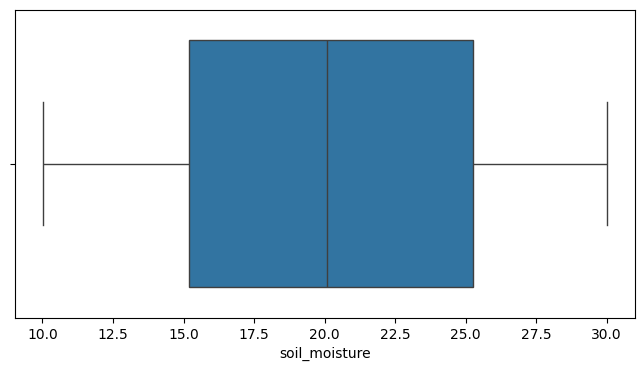

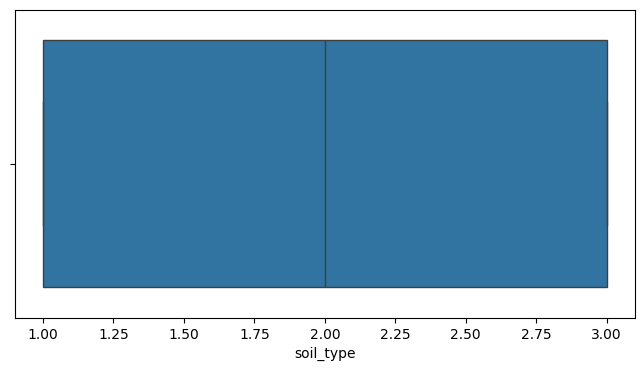

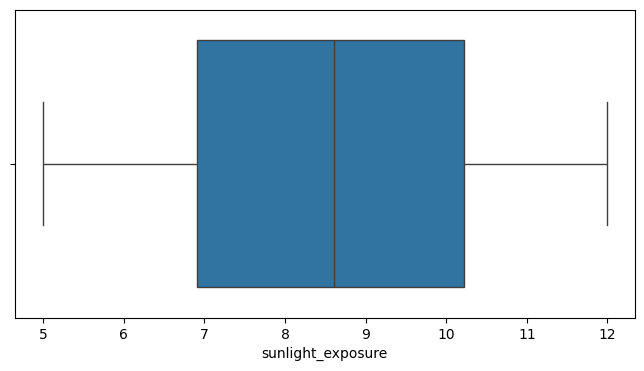

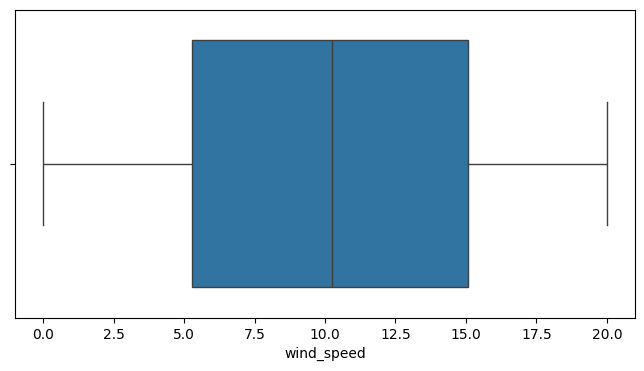

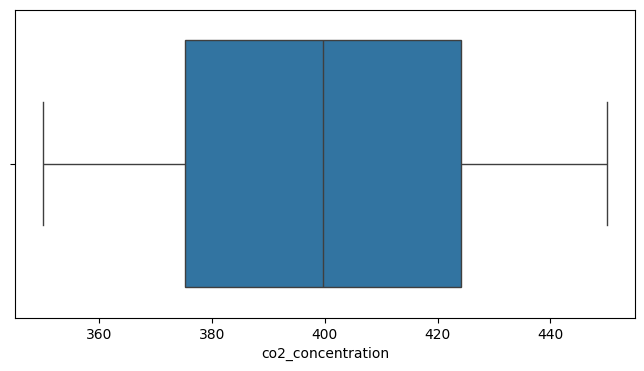

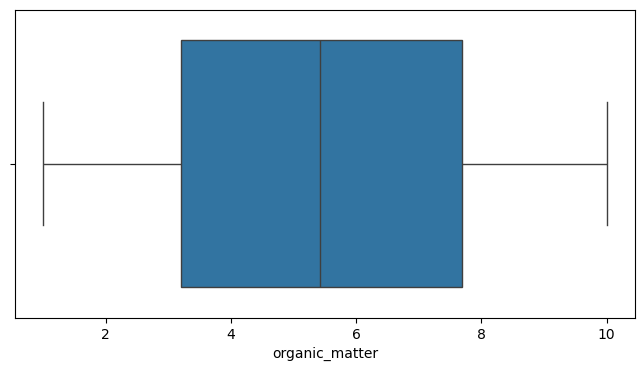

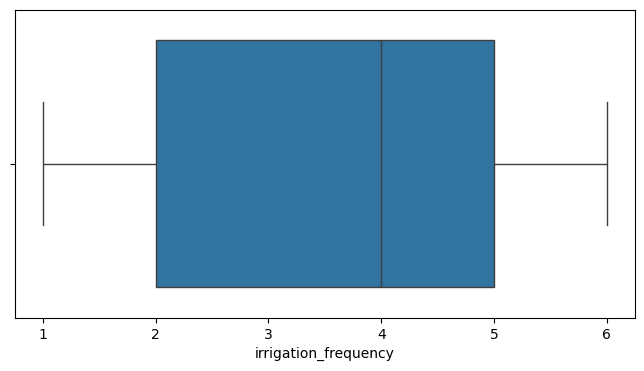

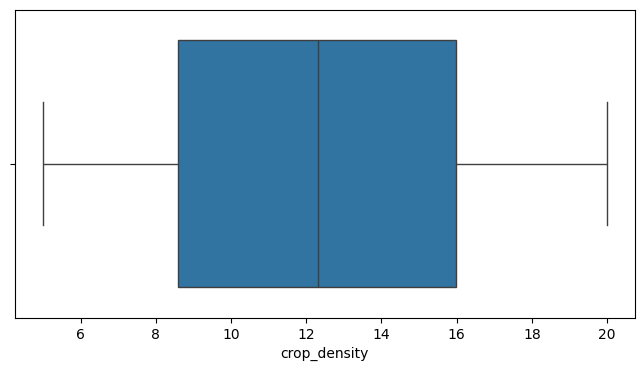

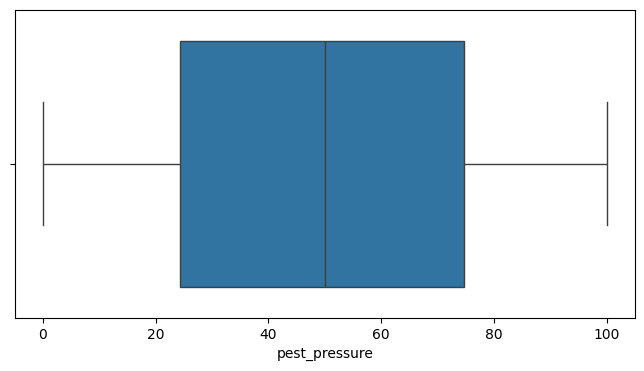

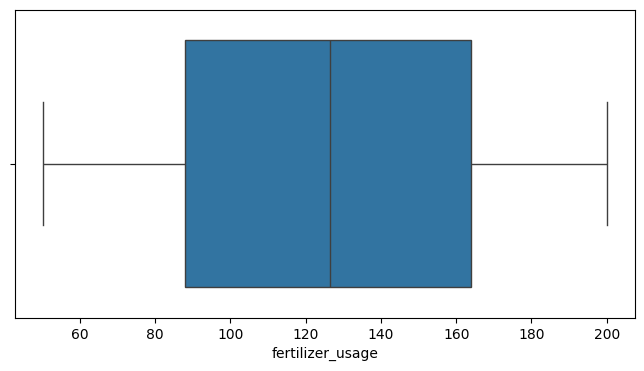

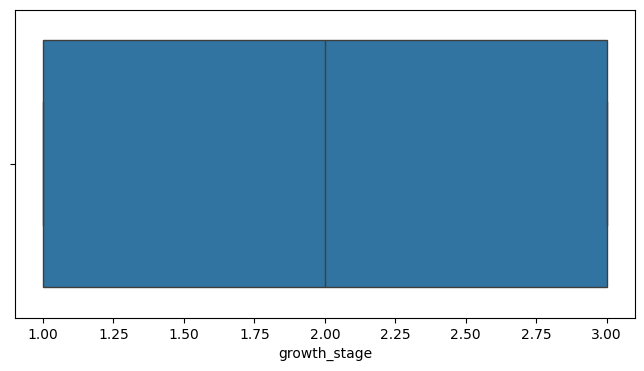

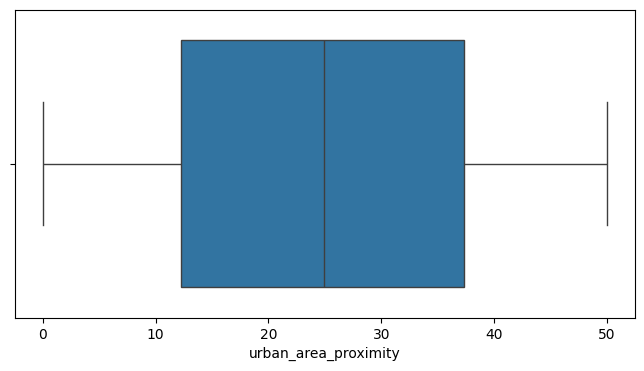

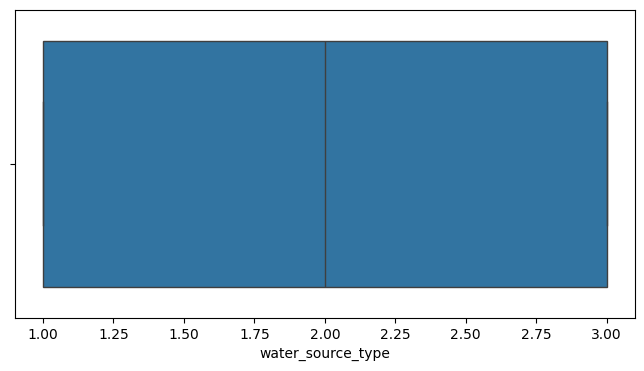

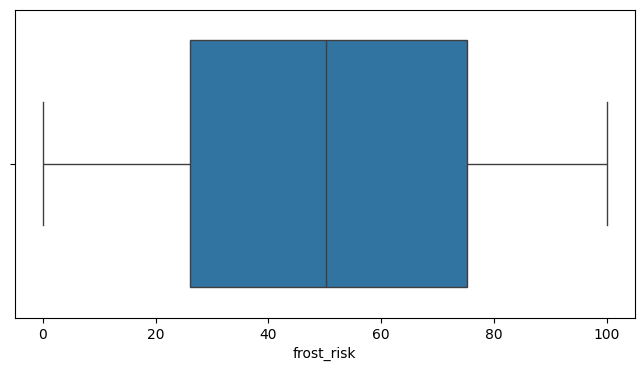

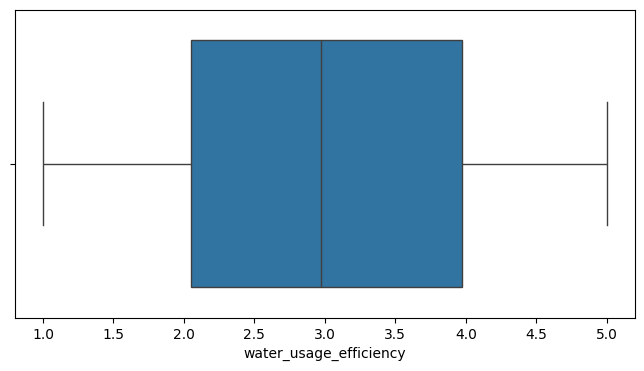

In [14]:
for col in df.select_dtypes('number'):
    boxplot(df,col)

In [15]:
df.rename(columns={'N': 'Nitrogen (ppm)', 'P':'Phosphorus (ppm)', 'K': 'Potassium (ppm)', 
                   'temperature':'Temperature (°C)', 
                   'humidity':'Humidity (%)' ,
                   'rainfall':'Rainfall (mm)',
                   'soil_moisture (%)':'Soil Moisture (%)',
                   'sunlight_exposure':'Sunlight Exposure (hrs/day)',
                   'wind_speed':'Wind Speed (km/h)',
                   'co2_concentration':'CO2 Concentration (ppm)',
                   'organic_matter':'Organic Matter (%)',
                   'irrigation_frequency':'Irrigation Frequency (times/week)',
                   'crop_density':'Crop Density (plants/m²)',
                   'pest_pressure':'Pest Pressure (index)',
                   'fertilizer_usage':'Fertilizer Usage (kg/hectare)',
                   'urban_area_proximity':'Urban Area Proximity (km)',
                   'frost_risk':'Frost Risk (index)',
                   'water_usage_efficiency':'Water Usage Efficiency (L/kg)'},inplace=True)

In [16]:
def st(a):
    if a == 1:
        return 'Sandy'
    elif a == 2:
        return 'Loamy'
    else:
        return 'Clay'
df['soil_type'] = df['soil_type'].apply(lambda x:st(x))

In [17]:
def gs(a):
    if a == 1:
        return 'Seedling'
    elif a == 2:
        return 'Vegetative'
    else:
        return 'Flowering'
df['growth_stage'] = df['growth_stage'].apply(lambda x:gs(x))

In [18]:
def ws(a):
    if a == 1:
        return 'River'
    elif a == 2:
        return 'Groundwater'
    else:
        return 'Recycled'
df['water_source_type'] = df['water_source_type'].apply(lambda x:ws(x))

---------------------------------------
## **Analysis & Statistical Tests**
---------------------------------------

- #### **Correlation**

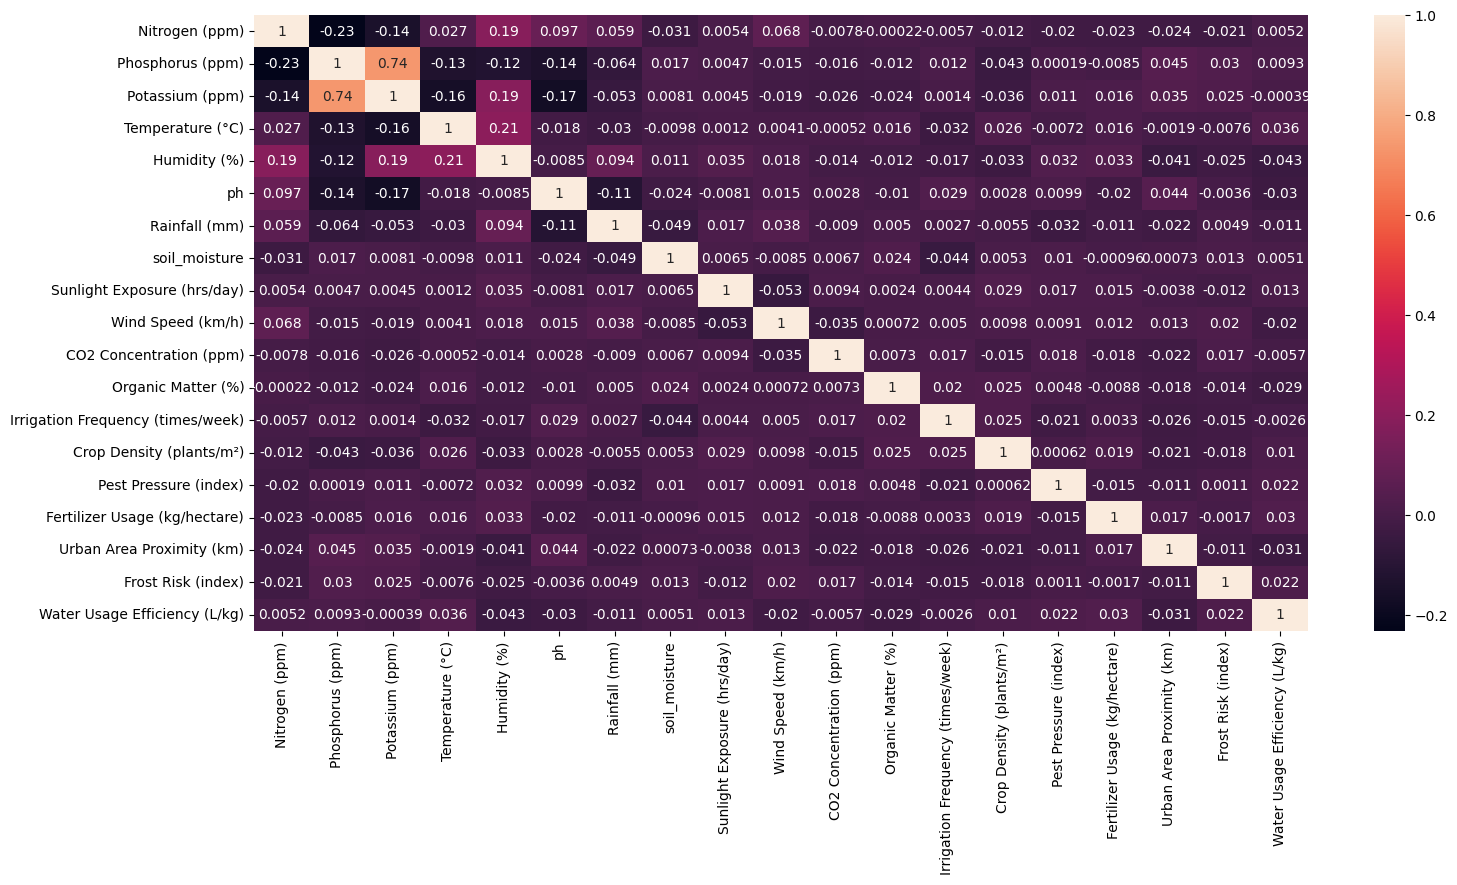

In [19]:
plt.figure(figsize=(17,	8))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

#### **1. The inverse relationship between nitrogen and phosphorus :**
- ##### In plant physiology, there is a concept called "nutrient antagonism." Excessive nitrogen fertilization leads to rapid and excessive vegetative growth, causing the plant to consume available phosphorus very quickly to meet the energy needs of growth, resulting in a phosphorus deficiency.

#### **2. The strong positive relationship between phosphorus and potassium :**
- ##### This is the strongest clear linear relationship in the matrix. Agriculturally, phosphorus and potassium work together as a complementary team; phosphorus builds strong, water-absorbing roots, and potassium regulates water use through the stomata and protects these roots from stress. Crops that require high energy to produce fruit (such as potatoes or tomatoes) always require balanced and high proportions of both. 

#### **3. The inverse relationship between pH and the two elements :**
- ##### The negative sign here means that as pH increases (i.e., the soil becomes alkaline/basic), the availability of phosphorus and potassium decreases. Phosphorus, in particular, is very sensitive to pH. In alkaline soils, it precipitates chemically with calcium, and in highly acidic soils, it precipitates with iron and aluminum. Therefore, its availability is best in a near-neutral environment. 

#### **4. The effect of heat and humidity on nutrients :**
- ##### High humidity and temperature increase the activity of microorganisms in the soil that carry out the process of "mineralization," which is the conversion of organic nitrogen and stable forms of potassium into soluble ionic forms that are easily detected and absorbed. Meanwhile, phosphorus availability may decrease due to the rapid absorption of phosphorus by plants under these ideal environmental conditions. 

#### **5. The inverse relationship between pH and rainfall :** 
- ##### A fundamentally chemecological explanation! Excessive rainfall leads to a chemical phenomenon known as "leaching," where water washes dissolved alkaline elements in the soil (such as calcium and magnesium) to deep underground layers, leaving behind hydrogen and aluminum ions, which causes an increase in soil acidity (i.e., a decrease in pH).

--------------------------------
- #### **Environmental & Weather Factors & Soil Nutrients** 
--------------------------------
- ##### **pH vs Label Analysis**

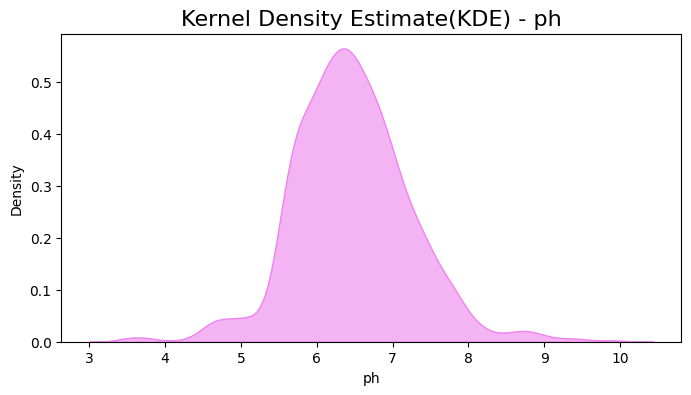

In [20]:
kde(df, 'ph')

##### Most crops share a preference for neutral soil

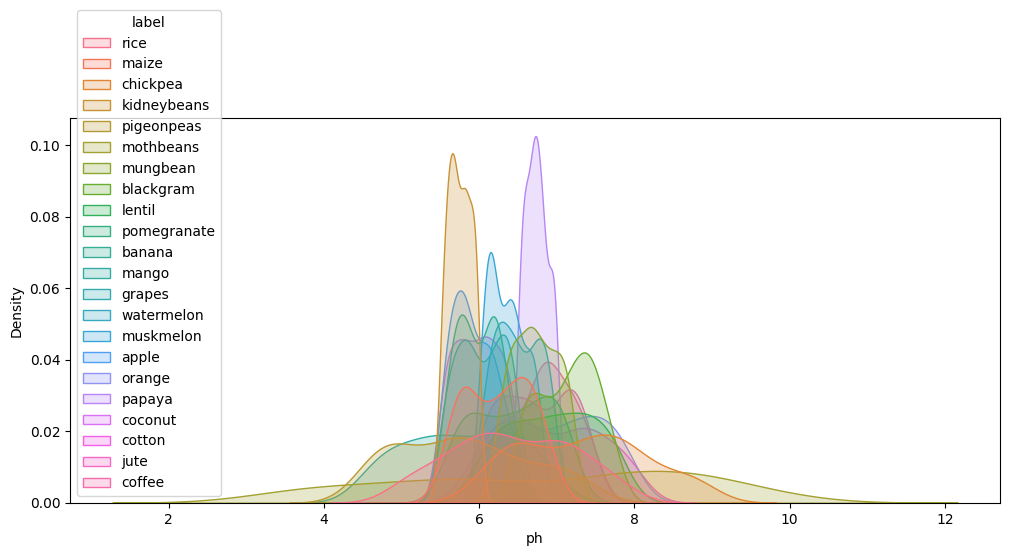

In [21]:
kdeSep(df,'ph','label')

- #### 1. Papaya - Purple Curve
##### pH is concentrated between 6.2 and 7.2
##### Agricultural Explanation:  Papaya prefers soil that is completely neutral to very slightly acidic. Within this range, the roots can easily absorb calcium and boron, which are crucial chemical elements for preventing the papaya fruit from becoming misshapen and ensuring its sweetness.

- #### 2. Common Beans (Kidneybeans) - Brown Curve
##### pH is concentrated between 5.4 and 6.1
##### Agricultural Explanation: this range is considered slightly acidic. Legumes in general (such as beans) require this slightly acidic environment because it stimulates the activity of Rhizobium bacteria living in their roots, which perform an important biochemical process: fixing atmospheric nitrogen in the soil to nourish the plant.

- #### 3. Apples - Blue Curve
##### pH is concentrated between 6.0 and 7.1 with a medium density (0.07)
##### Agricultural Interpretation: Apples are very adaptable and grow in slightly acidic to neutral soils. The lower density here (0.07 compared to papaya), that the apple values ​​in the data are more dispersed and spread over a wider range, rather than being concentrated in a narrow area.

- #### 4. Ray beans (mothbeans) - brownish-green curve
##### High Tolerance: Mothbeans are known in agriculture as one of the most drought- and harsh-conditioning crops. They thrive in highly acidic, neutral, and even alkaline soils.
##### Data Insight: This sprawling nature means that this plant has no specific pH preference; it grows almost anywhere! Therefore, the density is low because the samples are scattered along the axis and not clustered in one place. Agriculturally, pH is not a critical factor in determining the growth of this crop, and other factors such as drought or temperature may be more important.

--------------------------------
- ##### **Rainfall vs Label Analysis**

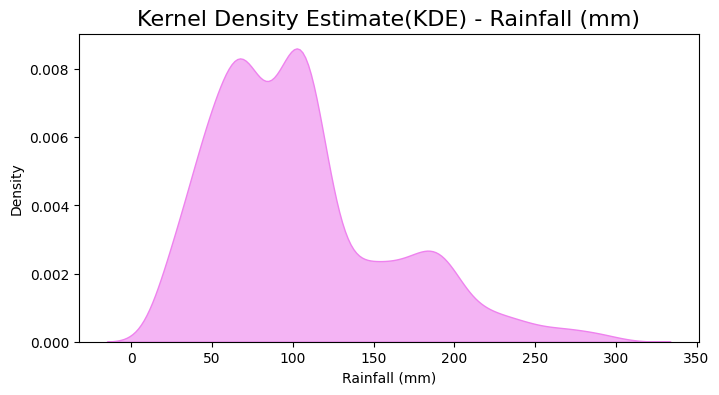

In [22]:
kde(df,'Rainfall (mm)')

##### General distribution of rainfall: Most crops in the data grow in conditions ranging from semi-arid to irrigated (between 30 and 140 mm)

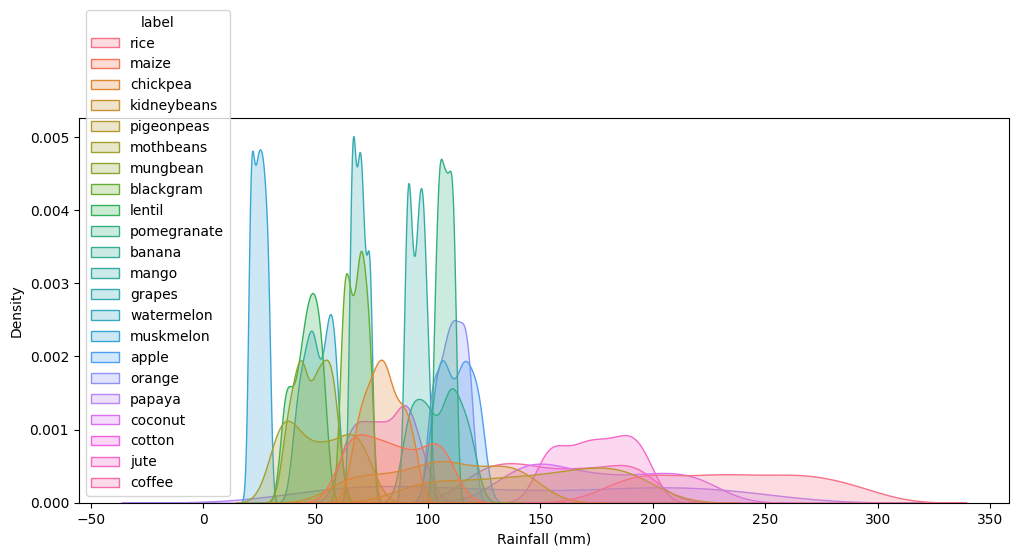

In [23]:
# Crop distribution according to rainfall
kdeSep(data=df, x='Rainfall (mm)', hue='label')

##### Semi-arid conditions: Crops such as lentils, mung beans, moth beans, and watermelon are isolated.

##### Wet conditions: Crops such as mangoes, apples, and coffee are isolated.

##### Very wet (tropical) conditions: Rice and coconuts are clearly isolated at the far right of the curve (above 200 mm).

--------------------------------
- ##### **Temperature vs Label Analysis**

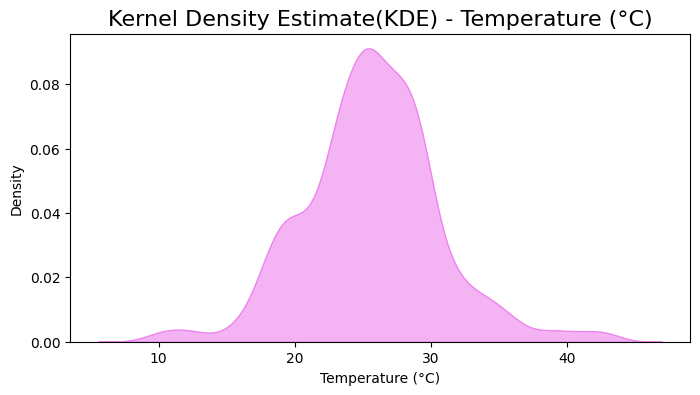

In [24]:
kde(df,'Temperature (°C)')

##### Most of the data clusters very densely between 23°C and 30°C.

##### Agricultural interpretation: This range represents the "ideal warm-season temperature," the optimal growing environment for most tropical and subtropical crops (such as rice, mango, papaya, and cotton) to accelerate metabolic and photosynthetic processes.

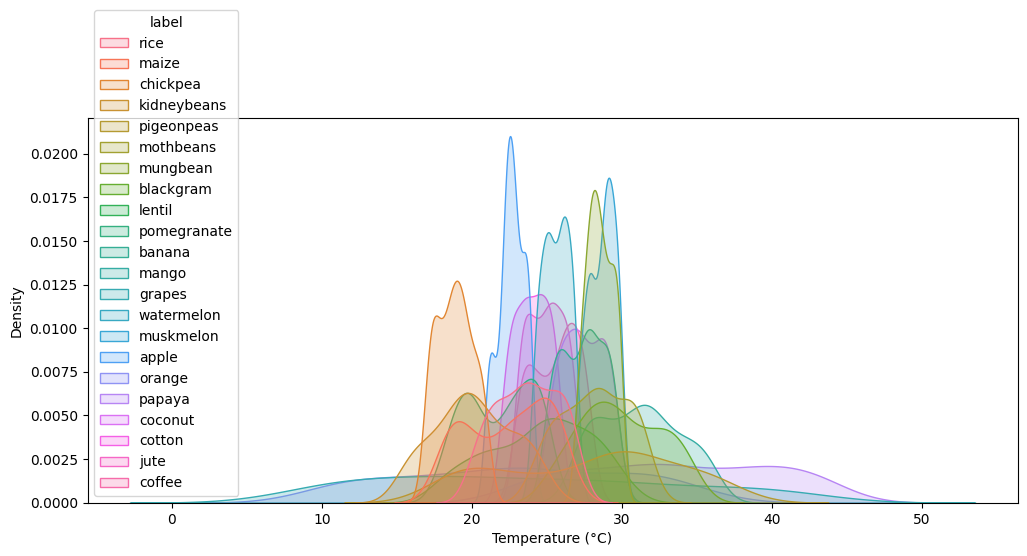

In [25]:
kdeSep(df,'Temperature (°C)','label')

#### 1. Normal Temperature Crops and Centering (20°C - 27°C)

- ##### Observation: Crops such as apples, maize, jute, pomegranate, rice, and watermelon are centered in this moderate range.

- ##### Agricultural Explanation: Your conclusion is absolutely correct; this is the golden range for rapid vegetative growth for most seasonal crops. Chemically and biologically, the photosynthetic enzymes in rice, watermelon, and corn function most efficiently at this moderate temperature, helping them store starch and sugars within the fruits and grains without experiencing heat stress.

#### 2. The Chickpea - Low Temperature Range (17°C - 21°C)

- ##### Observation: It clearly isolates itself in the cold, densely packed left side.

- ##### Agricultural Explanation: Chemically and biologically, chickpeas are considered a cool-season crop. The seeds require low temperatures for proper germination, and high temperatures prevent flowering and pod formation. Therefore, its isolation in this cold range is perfectly logical and scientifically sound.

#### 3. Grapes and Oranges – Environmental Resilience

- ##### Observation: They grow in almost all conditions, and their growth curves are flat and elongated.

- ##### Agricultural Explanation: Citrus fruits (like oranges) and grapes are perennial trees, not short-lived seasonal plants. These trees possess a resilient ecosystem capable of adapting to changing seasons (from cold winters to hot summers), and their cultivation is widespread globally in very diverse climates (such as the Mediterranean climate). Therefore, the data show them growing across a wide range of temperatures.

#### 4. Papaya: Tropical climate (high temperature and heavy rainfall together)
##### In regions near the equator (such as Malaysia, Indonesia, parts of India and Brazil, which are the native habitat of papaya).
- ##### The sun's rays are direct and very strong throughout the year, making the weather consistently hot (between 25°C and 30°C).
- ##### This intense heat leads to massive evaporation of water from the nearby oceans, filling the atmosphere with stifling humidity and forming dense clouds that produce heavy rainfall almost daily, often exceeding 200 mm.

--------------------------------
- ##### **Nutrients and Organic Matter vs Soil type Analysis**

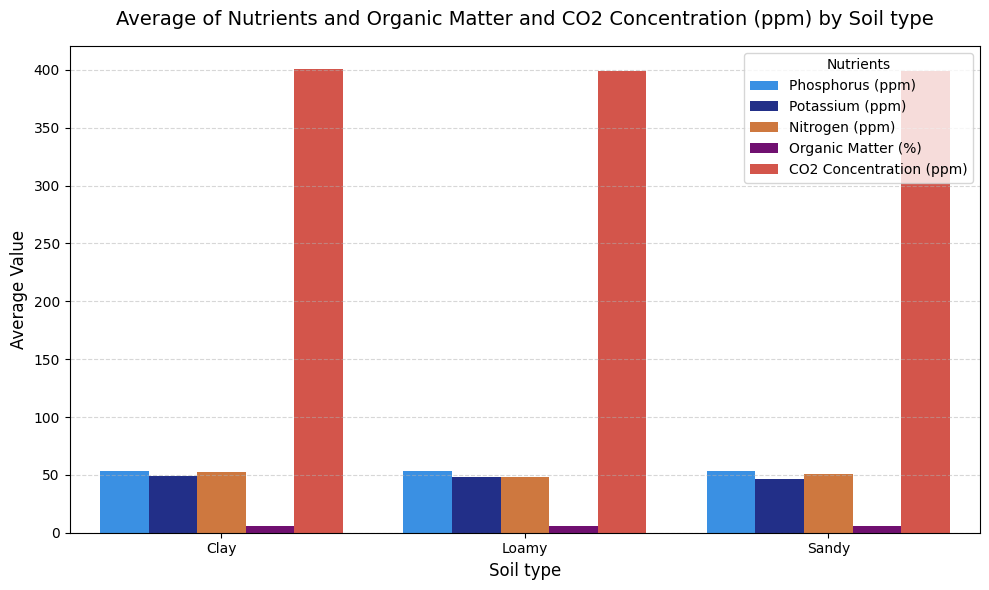

In [26]:
df_grouped = df.groupby('soil_type')[['Phosphorus (ppm)','Potassium (ppm)','Nitrogen (ppm)','Organic Matter (%)','CO2 Concentration (ppm)']].mean().reset_index()

df_melted = pd.melt(df_grouped, 
                    id_vars='soil_type', 
                    value_vars=['Phosphorus (ppm)','Potassium (ppm)','Nitrogen (ppm)','Organic Matter (%)','CO2 Concentration (ppm)'],
                    var_name='Nutrient', 
                    value_name='Average Value')

plt.figure(figsize=(10, 6))
custom_colors = ['#1e90ff', '#112299', '#e67327', '#800080','#e94235'] 

sns.barplot(data=df_melted, 
            x='soil_type', 
            y='Average Value', 
            hue='Nutrient', 
            palette=custom_colors)

plt.title('Average of Nutrients and Organic Matter and CO2 Concentration (ppm) by Soil type', fontsize=14, pad=15)
plt.xlabel('Soil type', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5) 
plt.legend(title='Nutrients')

plt.tight_layout()
plt.show()

In [27]:
from scipy import stats as st
loamy = df[df['soil_type']=='Loamy']['Potassium (ppm)']
sandy = df[df['soil_type']=='Sandy']['Potassium (ppm)']
clay = df[df['soil_type']=='Clay']['Potassium (ppm)']

stat, p_value_k = st.kruskal(loamy, sandy, clay)

print('soil type vs potassium')
print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")
        
if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

soil type vs potassium
Kruskal-Wallis Statistic: 3.2713507044756858
P-value: 0.1948207542278972
There is not a significant difference


In [28]:
loamy = df[df['soil_type']=='Loamy']['Phosphorus (ppm)']
sandy = df[df['soil_type']=='Sandy']['Phosphorus (ppm)']
clay = df[df['soil_type']=='Clay']['Phosphorus (ppm)']

stat, p_value_k = st.kruskal(loamy, sandy, clay)

print('soil type vs Phosphorus')
print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")
        
if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

soil type vs Phosphorus
Kruskal-Wallis Statistic: 0.170589462053382
P-value: 0.9182416102228461
There is not a significant difference


In [29]:
loamy = df[df['soil_type']=='Loamy']['Nitrogen (ppm)']
sandy = df[df['soil_type']=='Sandy']['Nitrogen (ppm)']
clay = df[df['soil_type']=='Clay']['Nitrogen (ppm)']

stat, p_value_k = st.kruskal(loamy, sandy, clay)

print('soil type vs Nitrogen')
print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")
        
if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

soil type vs Nitrogen
Kruskal-Wallis Statistic: 5.030154110043454
P-value: 0.08085668155330132
There is not a significant difference


In [30]:
loamy = df[df['soil_type']=='Loamy']['Organic Matter (%)']
sandy = df[df['soil_type']=='Sandy']['Organic Matter (%)']
clay = df[df['soil_type']=='Clay']['Organic Matter (%)']

stat, p_value_k = st.kruskal(loamy, sandy, clay)

print('soil type vs Organic Matter')
print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")
        
if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

soil type vs Organic Matter
Kruskal-Wallis Statistic: 0.6862321935064365
P-value: 0.7095558296501157
There is not a significant difference


##### Soil Type Equivalence: The test results indicate that the soil column in this group is determined in a way that does not suggest a significant fertilization difference, and that the relative proportions of materials are distributed or measured in a nearly balanced way across the clay, silt, and sand.

##### Average CO2 Concentration is the same in all types of soil  

##### Phosphorus vs. Organic Matter:  phosphorus registers the highest average concentration at 53 ppm in all types, while the relative organic matter is always around 5.5%, due to the natural difference in measurement between ppm and percentage.

--------------------------------
- #### **Farm Management** 
--------------------------------
- ##### **Soil type and Water source type vs Electrical Conductivity proxy**
-------------------------

In [31]:
df['Electrical_Conductivity_proxy'] = (df['Potassium (ppm)'] * 1.2 + df['Phosphorus (ppm)'] * 0.8) / (df['ph'] + 1e-5)

In [32]:
tab = pd.DataFrame(df.groupby(["soil_type","water_source_type"], sort=True)['Electrical_Conductivity_proxy'].mean()).reset_index()
tab

,soil_type,water_source_type,Electrical_Conductivity_proxy
0,Clay,Groundwater,16.024407
1,Clay,Recycled,15.779601
2,Clay,River,16.768541
3,Loamy,Groundwater,15.787670
4,Loamy,Recycled,16.671818
5,Loamy,River,16.089701
6,Sandy,Groundwater,16.628867
7,Sandy,Recycled,15.543840
8,Sandy,River,14.397282


In [33]:
def kruskal_test(soil):
    Groundwater = df[(df['soil_type'] == soil) & (df['water_source_type'] == 'Groundwater')]['Electrical_Conductivity_proxy']
    Recycled = df[(df['soil_type'] == soil) & (df['water_source_type'] == 'Recycled')]['Electrical_Conductivity_proxy']
    River = df[(df['soil_type'] == soil) & (df['water_source_type'] == 'River')]['Electrical_Conductivity_proxy']
    
    stat, p_value_k = st.kruskal(Groundwater, Recycled, River)

    print(f"Kruskal-Wallis Statistic: {stat}")
    print(f"P-value: {p_value_k}")
            
    if p_value_k < 0.05:
        print("There is a significant difference")
    else :
        print("There is not a significant difference")

In [34]:
for s in df['soil_type'].unique():
    print(s)
    kruskal_test(s)
    print('-----------------------')

Loamy
Kruskal-Wallis Statistic: 1.7698103775932064
P-value: 0.41275330506151375
There is not a significant difference
-----------------------
Clay
Kruskal-Wallis Statistic: 2.1834652310055116
P-value: 0.33563446415976533
There is not a significant difference
-----------------------
Sandy
Kruskal-Wallis Statistic: 0.5042309186446551
P-value: 0.7771550030986752
There is not a significant difference
-----------------------


##### Water source independence from salinity: The type of water source used for irrigation in these data does not produce significant differences in salinity levels within any given soil type.

-------------------------
- ##### **Soil type vs Fertilizer usage**

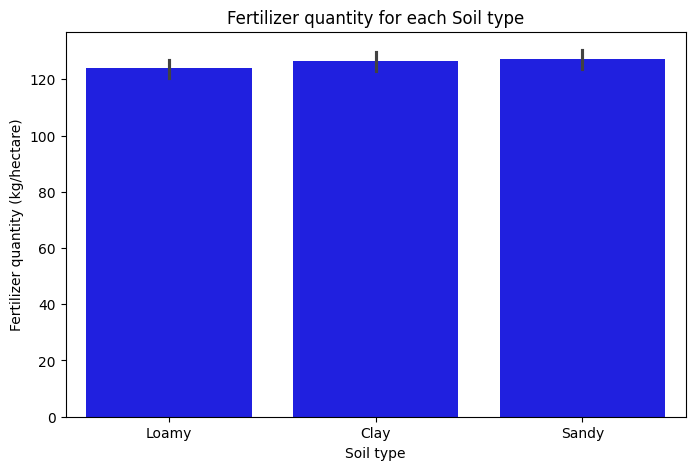

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='soil_type', y='Fertilizer Usage (kg/hectare)',color='b')
plt.title('Fertilizer quantity for each Soil type')
plt.xlabel('Soil type')
plt.ylabel('Fertilizer quantity (kg/hectare)')
plt.show()

In [38]:
loamy = df[df['soil_type']=='Loamy']['Fertilizer Usage (kg/hectare)']
sandy = df[df['soil_type']=='Sandy']['Fertilizer Usage (kg/hectare)']
clay = df[df['soil_type']=='Clay']['Fertilizer Usage (kg/hectare)']

stat, p_value_k = st.kruskal(loamy, sandy, clay)

print('soil type vs Nitrogen')
print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")
        
if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

soil type vs Nitrogen
Kruskal-Wallis Statistic: 2.030142617207538
P-value: 0.3623765883425878
There is not a significant difference


##### Fertilizer use is practically and structurally consistent across the three soil types (124-127 kg/ha)

--------------------------------

In [ ]:
# !jupyter nbconvert --to html "airbnb-price-analysis.ipynb"